In [17]:
from bloom_counter_filter import BloomCounterFilter
from typing import Tuple
import numpy as np
from infinite_str_stream_generation import infinite_str_stream_generation, get_set_of_unique_elements
import matplotlib.pyplot as plt
import pandas as pd


In [18]:

def calculate_false_positive_rate(n: int, eps: float,
                             num_trials: int,
                             per_of_fullness: float) -> Tuple[float, float]:
    results = []
    for _ in range(num_trials):
        bloom_counter_filter = BloomCounterFilter.make_filter_with_specified_accuracy(n=n, eps=eps)

        num_of_elements_to_add = int(np.ceil(n * per_of_fullness))

        elements_to_add = get_set_of_unique_elements(num_of_elements_to_add)

        for element in elements_to_add:
            bloom_counter_filter.add(element)

        unadded_elements = set()
        while len(unadded_elements) != num_of_elements_to_add:
            element = next(infinite_str_stream_generation())
            if element not in elements_to_add:
                unadded_elements.add(element)

        num_of_false_positive_elements = 0
        for element in unadded_elements:
            if bloom_counter_filter.element_is_in_filter(element):
                num_of_false_positive_elements += 1

        results.append(num_of_false_positive_elements/num_of_elements_to_add)

    mean = np.mean(results)
    variance = np.var(results)

    return mean, variance


In [19]:
n_values = (25000, 130000, 750000)
eps_values = (0.7, 0.15, 0.05)
pers_of_fullness = (0.25, 0.5, 0.75, 0.95)

results_of_experiments = []

for n, eps in zip(n_values, eps_values):
    for per in pers_of_fullness:

        mean, var = calculate_false_positive_rate(n=n, eps=eps, num_trials=3, per_of_fullness=per)
        k, m = BloomCounterFilter.calculate_k_and_m__with_specified_accuracy(n=n, eps=eps)
        theory_value = (1 - np.exp(-k*n/m)) ** k

        results_of_experiments.append({
            "n": n, "per": per * 100,
            "k": k, "m": m,
            "theory_value": theory_value * 100,
            "mean": mean * 100,
            "var": var
        })

results_of_experiments_df = pd.DataFrame(results_of_experiments)



In [21]:
results_of_experiments_df

,n,per,k,m,theory_value,mean,var
0,25000,25.0,1,18560,73.997637,28.378667,7.805156e-06
1,25000,50.0,1,18560,73.997637,48.797333,6.252089e-06
2,25000,75.0,1,18560,73.997637,63.392000,3.130785e-06
3,25000,95.0,1,18560,73.997637,72.735439,1.019194e-06
4,130000,25.0,3,513319,15.075735,0.529231,4.418146e-09
5,130000,50.0,3,513319,15.075735,3.201026,4.376068e-08
6,130000,75.0,3,513319,15.075735,8.176410,1.176068e-07
7,130000,95.0,3,513319,15.075735,13.615115,1.998976e-08
8,750000,25.0,5,4676419,5.102866,0.021867,2.104889e-09
9,750000,50.0,5,4676419,5.102866,0.389156,2.087980e-08


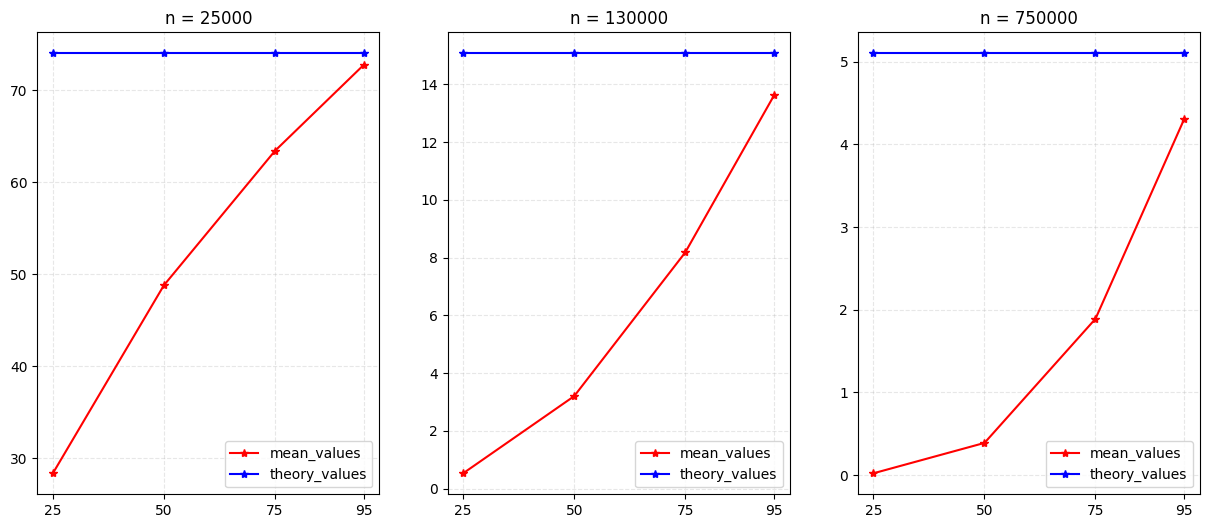

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, n in zip(axes, results_of_experiments_df["n"].unique()):
    data_with_curr_n = results_of_experiments_df[results_of_experiments_df["n"] == n]
    ax.plot(data_with_curr_n["per"], data_with_curr_n["mean"], marker="*", color="red", label="mean_values")
    ax.plot(data_with_curr_n["per"], data_with_curr_n["theory_value"], marker="*", color="blue", label="theory_values")

    ax.set_title(f"n = {n}")
    ax.legend()
    ax.set_xticks([25, 50, 75, 95])
    ax.grid(True, alpha=0.3, linestyle='--')